In [1]:
import pandas as pd
system = pd.read_csv("2024_processed_leidingen_glisexport.csv", sep=";")
system.columns = ["null_ID", "Batch_year", "Construction_year", "ID", "Length", "Diameter", "Material", "Water_company","External_protection", "Internal_protection", "Relining","Cathodic_protection"]
system["Construction_year"] = system[system["Construction_year"]>=1500]["Construction_year"]
system


,null_ID,Batch_year,Construction_year,ID,Length,Diameter,Material,Water_company,External_protection,Internal_protection,Relining,Cathodic_protection
0,2166783,2018,1974.0,233514287,368.595185,200,MAT_AC,B,BU_AC_GEEN,-,RELIN_NEE,-
1,2196114,2019,1968.0,177852534,117.991714,100,MAT_GG,B,-,-,RELIN_NEE,KB_NEE
2,2055089,2018,2001.0,177622476,39.556610,100,MAT_NG,B,BU_NG_PE,BI_NG_CL,RELIN_NEE,KB_NEE
3,1668377,2016,2001.0,-1,6436.656000,504,MAT_NG,C,-,-,-,-
4,2115381,2018,1992.0,178402238,31.352994,100,MAT_NG,B,BU_NG_PE,BI_NG_CL,RELIN_NEE,KB_NEE
...,...,...,...,...,...,...,...,...,...,...,...,...
80857,2073596,2018,1989.0,177860883,36.457173,110,MAT_PVC,B,-,-,RELIN_NEE,-
80858,2126919,2018,1989.0,178554099,7.511757,200,MAT_AC,B,BU_AC_GEEN,-,RELIN_NEE,-
80859,2113317,2018,1992.0,178370569,104.638249,100,MAT_NG,B,BU_NG_PE,BI_NG_CL,RELIN_NEE,KB_NEE
80860,2115420,2018,1966.0,178402661,129.786245,100,MAT_AC,B,BU_AC_GEEN,-,RELIN_NEE,-


In [2]:
system_cleaned = system.drop_duplicates(subset=["ID","Length","Material", "Diameter", "Water_company","Construction_year"]).copy()
system_cleaned

,null_ID,Batch_year,Construction_year,ID,Length,Diameter,Material,Water_company,External_protection,Internal_protection,Relining,Cathodic_protection
0,2166783,2018,1974.0,233514287,368.595185,200,MAT_AC,B,BU_AC_GEEN,-,RELIN_NEE,-
1,2196114,2019,1968.0,177852534,117.991714,100,MAT_GG,B,-,-,RELIN_NEE,KB_NEE
2,2055089,2018,2001.0,177622476,39.556610,100,MAT_NG,B,BU_NG_PE,BI_NG_CL,RELIN_NEE,KB_NEE
3,1668377,2016,2001.0,-1,6436.656000,504,MAT_NG,C,-,-,-,-
4,2115381,2018,1992.0,178402238,31.352994,100,MAT_NG,B,BU_NG_PE,BI_NG_CL,RELIN_NEE,KB_NEE
...,...,...,...,...,...,...,...,...,...,...,...,...
80857,2073596,2018,1989.0,177860883,36.457173,110,MAT_PVC,B,-,-,RELIN_NEE,-
80858,2126919,2018,1989.0,178554099,7.511757,200,MAT_AC,B,BU_AC_GEEN,-,RELIN_NEE,-
80859,2113317,2018,1992.0,178370569,104.638249,100,MAT_NG,B,BU_NG_PE,BI_NG_CL,RELIN_NEE,KB_NEE
80860,2115420,2018,1966.0,178402661,129.786245,100,MAT_AC,B,BU_AC_GEEN,-,RELIN_NEE,-


In [3]:

removed = len(system) - len(system_cleaned)
print(f"Removed {removed} duplicate rows.")
system_cleaned["Material"].unique()

Removed 9998 duplicate rows.


array(['MAT_AC', 'MAT_GG', 'MAT_NG', 'MAT_PVCV', 'MAT_PVC', 'MAT_ST',
       'MAT_PE_AND', 'MAT_PE', 'MAT_AND', 'MAT_BET'], dtype=object)

/var/folders/lb/mknkjv6j7xx0ynj8lks1cv100000gn/T/ipykernel_6411/2640955221.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  system_cleaned['Construction_year'] = system_cleaned['Construction_year'].astype(int)


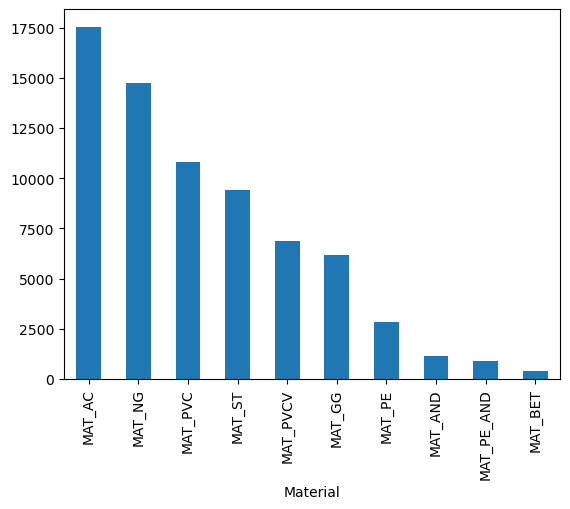

In [4]:
system_cleaned["Material"].value_counts().plot.bar()
# Drop rows where Construction_year is NaN
system_cleaned = system_cleaned.dropna(subset=['Construction_year'])
system_cleaned['Construction_year'] = system_cleaned['Construction_year'].astype(int)

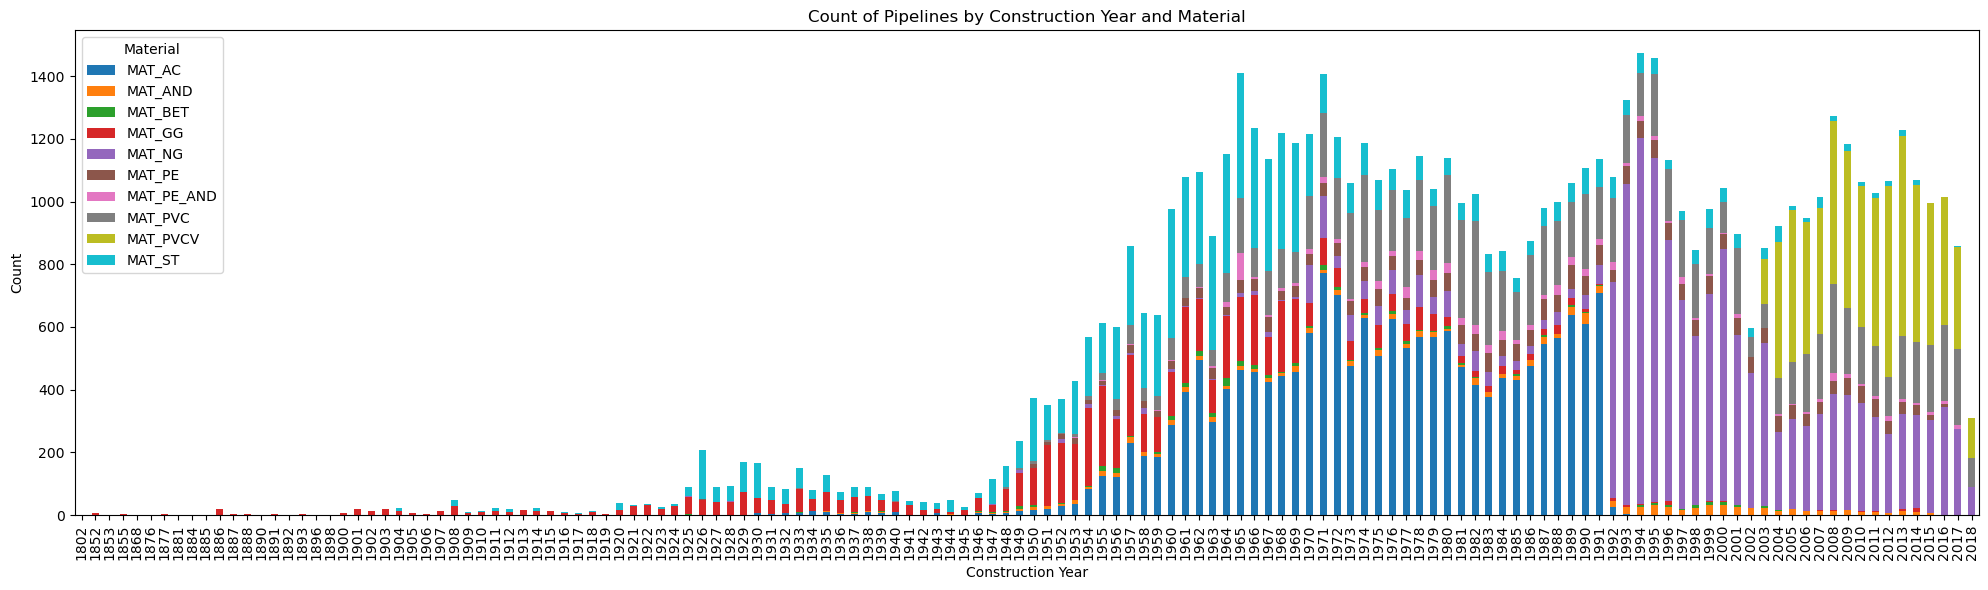

In [5]:
import matplotlib.pyplot as plt
count = system_cleaned.groupby(["Construction_year", "Material"]).size().unstack(fill_value=0)
ax = count.plot(kind="bar", stacked=True, figsize=(20, 6))
ax.set_xlabel("Construction Year")
ax.set_ylabel("Count")
ax.set_title("Count of Pipelines by Construction Year and Material")
plt.legend(title="Material")
plt.tight_layout()
plt.show()

In [6]:
system_cleaned["Diameter"].unique()

array([ 200,  100,  504,  110,   50,   63,  150,  204,   80,  160,  111,
        800,   40,  970,  400,  125,  250,  315,   32,   21,   51,  500,
        118,   25,   90,  300,  235,  194,  251,  350,  692,   28,   75,
        151,  600,  700,  175,  309,  355,   31, 1500,  560,  154,  102,
         20,  231,  463,  610,   66,  481,   49,  900,   35, 1200,  304,
        450,  770,  769,   45,  115,  306,  103,  377,  380,   54,  142,
        188,  126,   15,   98,  221, 1169,   85,  297,   22,  215,   42,
        980,   71,   -1,  516,  541,  116,  195,    1,  616,  178,   52,
         16,  704,   27,   77,  279,  381,   55,   53,   39,   26,  583,
        128,  762,  386,  152,   92,   97,  471,  630, 1000,  177,  508,
        255,  896,  222,   43,   13,  219,  679, 1492,  301,   59,  403,
         93,  225,   44,  205,   60,  258,   30,  506,  275,  876,  807,
        294,  198,  605,  618,  620,  288,  211,  244,  254,  710,   67,
        443,  144, 1400,  569,   34,  140,  401,   